# [실습] 텍스트 분석 시스템 만들기

## 학습목표
- 텍스트 분석 파이프라인을 설계하고 구현할 수 있다
- 파일 입출력을 통해 대량의 텍스트를 처리할 수 있다
- 분석 결과를 리포트로 생성할 수 있다

## 시스템 설정 및 초기화

프로젝트에 필요한 설정과 디렉토리를 준비합니다.

In [1]:
import numpy as np
import pandas as pd
import json
import re
import os
import pickle
from collections import Counter, defaultdict
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

# 프로젝트 디렉토리 구조
DIRS = {
    'input': './input_files',
    'output': './output_files',
    'models': './models',
    'reports': './reports',
}

# 디렉토리 생성
for dir_name, dir_path in DIRS.items():
    os.makedirs(dir_path, exist_ok=True)
    print(f"✓ {dir_name}: {dir_path}")


# 불용어 리스트
stopwords_txt = './stopwords_ko.txt'
with open(stopwords_txt, 'r', encoding='utf-8') as f:
    KOREAN_STOPWORDS = [line.strip() for line in f.readlines()]
print(KOREAN_STOPWORDS)

print("\n시스템 초기화 완료!")

✓ input: ./input_files
✓ output: ./output_files
✓ models: ./models
✓ reports: ./reports
['은', '는', '이', '가', '을', '를', '에', '의', '와', '과', '로', '으로', '에서', '에게', '까지', '부터', '도', '만', '라고', '하고', '하는', '하다', '있다', '되다', '이다', '그', '그리고', '및', '또는', '또한', '즉', '다시', '또', '이미', '더', '그러나', '하지만', '그런데', '그래서', '따라서']

시스템 초기화 완료!


## 텍스트 전처리 모듈

In [2]:
class TextPreprocessor:
    """텍스트 전처리 클래스"""
    
    def __init__(self, stopwords=None):
        self.stopwords = set(stopwords or KOREAN_STOPWORDS)
        
    def clean_text(self, text):
        """텍스트 정제"""
        # HTML 태그 제거
        text = re.sub(r'<[^>]+>', '', text)
        # URL 제거
        text = re.sub(r'http[s]?://\S+', '', text)
        # 이메일 제거
        text = re.sub(r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}', '', text)
        # 특수문자를 공백으로
        text = re.sub(r'[^가-힣a-zA-Z0-9\s.,!?]', ' ', text)
        # 연속된 공백 제거
        text = re.sub(r'\s+', ' ', text)
        return text.strip()
    
    def tokenize(self, text):
        """토큰화"""
        tokens = text.lower().split()
        return [t for t in tokens if len(t) >= 2]
    
    def remove_stopwords(self, tokens):
        """불용어 제거"""
        return [t for t in tokens if t not in self.stopwords]
    
    def normalize(self, text):
        """정규화"""
        text = text.lower()
        text = re.sub(r'\d+', 'NUM', text)
        text = re.sub(r'(.)\1{2,}', r'\1\1', text)
        return text
    
    def preprocess(self, text):
        """전체 전처리 파이프라인"""
        text = self.clean_text(text)
        text = self.normalize(text)
        tokens = self.tokenize(text)
        tokens = self.remove_stopwords(tokens)
        
        return {
            'cleaned_text': ' '.join(tokens),
            'tokens': tokens,
            'token_count': len(tokens)
        }

print("전처리 모듈 로드 완료")

전처리 모듈 로드 완료


## 특징 추출 모듈

In [3]:
class FeatureExtractor:
    """특징 추출 클래스"""
    
    def __init__(self, max_features=1000):
        self.max_features = max_features
        self.vocabulary = {}
        self.idf_values = {}
        
    def fit(self, documents):
        """문서 집합으로부터 학습"""
        vocab_counter = Counter()
        doc_freq = defaultdict(int)
        
        for doc in documents:
            words = doc.lower().split()
            unique_words = set(words)
            vocab_counter.update(words)
            
            for word in unique_words:
                doc_freq[word] += 1
        
        # 상위 N개 단어만 선택
        most_common = vocab_counter.most_common(self.max_features)
        self.vocabulary = {word: idx for idx, (word, _) in enumerate(most_common)}
        
        # IDF 계산
        n_docs = len(documents)
        for word in self.vocabulary:
            self.idf_values[word] = np.log(n_docs / (doc_freq[word] + 1))
        
        return self
    
    def extract_bow(self, text):
        """BOW 특징 추출"""
        vector = np.zeros(len(self.vocabulary))
        words = text.lower().split()
        
        for word in words:
            if word in self.vocabulary:
                vector[self.vocabulary[word]] += 1
        
        return vector
    
    def extract_tfidf(self, text):
        """TF-IDF 특징 추출"""
        words = text.lower().split()
        word_count = Counter(words)
        doc_length = len(words)
        
        vector = np.zeros(len(self.vocabulary))
        
        if doc_length == 0:
            return vector
        
        for word, count in word_count.items():
            if word in self.vocabulary:
                tf = count / doc_length
                idf = self.idf_values[word]
                vector[self.vocabulary[word]] = tf * idf
        
        return vector
    
    def extract_statistics(self, text):
        """통계적 특징 추출"""
        words = text.split()
        sentences = re.split(r'[.!?]+', text)
        
        return {
            'char_count': len(text),
            'word_count': len(words),
            'sentence_count': len([s for s in sentences if s.strip()]),
            'avg_word_length': np.mean([len(w) for w in words]) if words else 0,
            'unique_word_ratio': len(set(words)) / len(words) if words else 0,
            'punctuation_count': len(re.findall(r'[.,!?;:]', text))
        }

print("특징 추출 모듈 로드 완료")

특징 추출 모듈 로드 완료


## 텍스트 분석 엔진

In [4]:
class TextAnalyzer:
    """통합 텍스트 분석 엔진"""
    
    def __init__(self):
        self.preprocessor = TextPreprocessor()
        self.feature_extractor = FeatureExtractor()
        self.is_trained = False
        
    def train(self, corpus):
        """코퍼스로 학습"""
        print(f"학습 시작: {len(corpus)}개 문서")
        
        processed_docs = []
        for doc in corpus:
            result = self.preprocessor.preprocess(doc)
            processed_docs.append(result['cleaned_text'])
        
        self.feature_extractor.fit(processed_docs)
        self.is_trained = True
        
        print(f"✓ 학습 완료: {len(self.feature_extractor.vocabulary)}개 단어")
        return self
    
    def analyze(self, text):
        """텍스트 분석"""
        # 전처리
        preprocessing = self.preprocessor.preprocess(text)
        
        # 통계적 특징
        statistics = self.feature_extractor.extract_statistics(text)
        
        # 키워드 추출
        keywords = Counter(preprocessing['tokens']).most_common(10)
        
        # 감정 분석
        sentiment = self._analyze_sentiment(text)
        
        # 카테고리 예측
        category = self._predict_category(preprocessing['cleaned_text'])
        
        # N-gram 추출
        bigrams = self._extract_ngrams(preprocessing['tokens'], n=2)
        
        return {
            'preprocessing': preprocessing,
            'statistics': statistics,
            'keywords': keywords,
            'sentiment': sentiment,
            'category': category,
            'bigrams': bigrams[:5],
            'timestamp': datetime.now().isoformat()
        }
    
    def _analyze_sentiment(self, text):
        """감정 분석"""
        positive_words = ['좋', '훌륭', '최고', '만족', '추천', '긍정', '성공', '우수', '뛰어']
        negative_words = ['나쁘', '별로', '실망', '부정', '실패', '문제', '어렵', '불만', '최악']
        
        text_lower = text.lower()
        pos_score = sum(1 for word in positive_words if word in text_lower)
        neg_score = sum(1 for word in negative_words if word in text_lower)
        
        total = pos_score + neg_score + 1
        
        if pos_score > neg_score:
            return {'label': '긍정', 'confidence': pos_score / total}
        elif neg_score > pos_score:
            return {'label': '부정', 'confidence': neg_score / total}
        else:
            return {'label': '중립', 'confidence': 0.5}
    
    def _predict_category(self, text):
        """카테고리 예측"""
        categories = {
            'AI/ML': ['인공지능', 'ai', '머신러닝', '딥러닝', '학습', '모델', '신경망'],
            '개발': ['프로그래밍', '코드', '개발', '파이썬', 'python', 'java', '함수'],
            '데이터': ['데이터', '분석', '통계', '빅데이터', '처리', '시각화'],
            '비즈니스': ['경영', '매출', '투자', '시장', '고객', '전략', '수익']
        }
        
        text_lower = text.lower()
        scores = {}
        
        for category, keywords in categories.items():
            score = sum(1 for kw in keywords if kw in text_lower)
            scores[category] = score
        
        if max(scores.values()) == 0:
            return {'category': '기타', 'confidence': 0.0}
        
        best_category = max(scores, key=scores.get)
        total_score = sum(scores.values())
        
        return {
            'category': best_category,
            'confidence': scores[best_category] / total_score if total_score > 0 else 0
        }
    
    def _extract_ngrams(self, tokens, n=2):
        """N-gram 추출"""
        ngrams = []
        for i in range(len(tokens) - n + 1):
            ngram = ' '.join(tokens[i:i+n])
            ngrams.append(ngram)
        
        return Counter(ngrams).most_common()
    
    def save_model(self, filepath):
        """모델 저장"""
        model_data = {
            'vocabulary': self.feature_extractor.vocabulary,
            'idf_values': self.feature_extractor.idf_values,
            'is_trained': self.is_trained
        }
        
        with open(filepath, 'wb') as f:
            pickle.dump(model_data, f)
        print(f"✓ 모델 저장: {filepath}")
    
    def load_model(self, filepath):
        """모델 로드"""
        with open(filepath, 'rb') as f:
            model_data = pickle.load(f)
        
        self.feature_extractor.vocabulary = model_data['vocabulary']
        self.feature_extractor.idf_values = model_data['idf_values']
        self.is_trained = model_data['is_trained']
        print(f"✓ 모델 로드: {filepath}")

print("분석 엔진 로드 완료")

분석 엔진 로드 완료


## 파일 입출력 처리

In [5]:
class FileProcessor:
    """파일 입출력 처리 클래스"""
    
    @staticmethod
    def read_text_file(filepath):
        """텍스트 파일 읽기"""
        with open(filepath, 'r', encoding='utf-8') as f:
            return f.read()
    
    @staticmethod
    def read_json_file(filepath):
        """JSON 파일 읽기"""
        with open(filepath, 'r', encoding='utf-8') as f:
            return json.load(f)
    
    @staticmethod
    def save_results(results, filepath):
        """분석 결과 저장"""
        with open(filepath, 'w', encoding='utf-8') as f:
            json.dump(results, f, ensure_ascii=False, indent=2)
        print(f"✓ 결과 저장: {filepath}")
    
    @staticmethod
    def process_directory(directory, analyzer):
        """디렉토리 내 모든 텍스트 파일 처리"""
        results = []
        
        for filename in os.listdir(directory):
            if filename.endswith('.txt'):
                filepath = os.path.join(directory, filename)
                text = FileProcessor.read_text_file(filepath)
                
                analysis = analyzer.analyze(text)
                analysis['filename'] = filename
                results.append(analysis)
                
                print(f"  처리: {filename}")
        
        return results

print("파일 처리 모듈 로드 완료")

파일 처리 모듈 로드 완료


## 리포트 생성

In [6]:
class ReportGenerator:
    """분석 리포트 생성 클래스"""
    
    @staticmethod
    def generate_summary(results):
        """전체 분석 요약"""
        summary = {
            'total_documents': len(results),
            'total_words': sum(r['statistics']['word_count'] for r in results),
            'avg_words': np.mean([r['statistics']['word_count'] for r in results]),
            'sentiment_distribution': Counter([r['sentiment']['label'] for r in results]),
            'category_distribution': Counter([r['category']['category'] for r in results])
        }
        
        # 전체 키워드 집계
        all_keywords = []
        for result in results:
            all_keywords.extend([kw for kw, _ in result['keywords']])
        summary['top_keywords'] = Counter(all_keywords).most_common(20)
        
        return summary
    
    @staticmethod
    def generate_text_report(results, output_path):
        """텍스트 형식 리포트 생성"""
        summary = ReportGenerator.generate_summary(results)
        
        report = []
        report.append("="*60)
        report.append("텍스트 분석 리포트")
        report.append("="*60)
        report.append(f"\n생성 시간: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        report.append(f"분석 문서 수: {summary['total_documents']}개")
        report.append(f"총 단어 수: {summary['total_words']:,}개")
        report.append(f"평균 단어 수: {summary['avg_words']:.1f}개\n")
        
        report.append("\n[감정 분포]")
        for sentiment, count in summary['sentiment_distribution'].items():
            pct = count / summary['total_documents'] * 100
            report.append(f"  {sentiment}: {count}개 ({pct:.1f}%)")
        
        report.append("\n[카테고리 분포]")
        for category, count in summary['category_distribution'].items():
            pct = count / summary['total_documents'] * 100
            report.append(f"  {category}: {count}개 ({pct:.1f}%)")
        
        report.append("\n[상위 20개 키워드]")
        for i, (keyword, freq) in enumerate(summary['top_keywords'], 1):
            report.append(f"  {i:2d}. {keyword}: {freq}회")
        
        report.append("\n" + "="*60)
        report.append("[개별 문서 분석 결과]")
        report.append("="*60)
        
        for i, result in enumerate(results, 1):
            report.append(f"\n[{i}] {result.get('filename', 'Unknown')}")
            report.append(f"  - 단어 수: {result['statistics']['word_count']}")
            report.append(f"  - 감정: {result['sentiment']['label']} ({result['sentiment']['confidence']:.2f})")
            report.append(f"  - 카테고리: {result['category']['category']} ({result['category']['confidence']:.2f})")
            report.append(f"  - 주요 키워드: {', '.join([kw for kw, _ in result['keywords'][:5]])}")
        
        # 파일로 저장
        report_text = '\n'.join(report)
        with open(output_path, 'w', encoding='utf-8') as f:
            f.write(report_text)
        
        print(f"✓ 리포트 생성: {output_path}")
        return report_text
    
    @staticmethod
    def generate_visualization(results, output_dir):
        """시각화 생성"""
        
        plt.rcParams['font.family'] = 'Malgun Gothic'
        # 한글 폰트 로드 (없으면 'NanumGothic'이나 'Dejavu Sans')


        summary = ReportGenerator.generate_summary(results)
        
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        
        # 1. 감정 분포
        sentiments = list(summary['sentiment_distribution'].keys())
        sentiment_counts = list(summary['sentiment_distribution'].values())
        axes[0, 0].pie(sentiment_counts, labels=sentiments, autopct='%1.1f%%')
        axes[0, 0].set_title('Sentiment Distribution')
        
        # 2. 카테고리 분포
        categories = list(summary['category_distribution'].keys())
        category_counts = list(summary['category_distribution'].values())
        axes[0, 1].bar(categories, category_counts, color='skyblue')
        axes[0, 1].set_title('Category Distribution')
        axes[0, 1].set_xlabel('Category')
        axes[0, 1].set_ylabel('Count')
        axes[0, 1].tick_params(axis='x', rotation=45)
        
        # 3. 상위 키워드
        top_10_keywords = summary['top_keywords'][:10]
        keywords = [kw for kw, _ in top_10_keywords]
        freqs = [freq for _, freq in top_10_keywords]
        axes[1, 0].barh(keywords[::-1], freqs[::-1], color='coral')
        axes[1, 0].set_title('Top 10 Keywords')
        axes[1, 0].set_xlabel('Frequency')
        
        # 4. 문서 길이 분포
        word_counts = [r['statistics']['word_count'] for r in results]
        axes[1, 1].hist(word_counts, bins=15, color='lightgreen', edgecolor='black')
        axes[1, 1].set_title('Document Length Distribution')
        axes[1, 1].set_xlabel('Word Count')
        axes[1, 1].set_ylabel('Frequency')
        axes[1, 1].axvline(np.mean(word_counts), color='red', linestyle='--', label='Mean')
        axes[1, 1].legend()
        
        plt.tight_layout()
        
        # 저장
        viz_path = os.path.join(output_dir, 'analysis_visualization.png')
        plt.savefig(viz_path, dpi=100, bbox_inches='tight')
        plt.show()
        
        print(f"✓ 시각화 저장: {viz_path}")

print("리포트 생성 모듈 로드 완료")

리포트 생성 모듈 로드 완료


## 시스템 실행

전체 시스템을 실행하여 텍스트를 분석합니다.

In [7]:
# 샘플 텍스트 파일 생성
sample_texts = {
    'ai_article.txt': """2025년 현재 인공지능과 머신러닝은 여전히 현대 기술 혁신의 핵심이며, 산업 전반에서 가장 중요한 화두로 자리잡고 있습니다. 
특히 최근 2년간 발전한 대규모 언어모델(LLM)은 텍스트 생성, 자동 번역, 고객 응대 챗봇 등 실무 현장에서 빠르게 확산되고 있으며, 실제 기업 운영 효율을 극대화하고 있습니다. 
딥러닝 모델은 이미지 인식, 자율주행차, 음성 비서뿐 아니라 의료 진단, 신약 개발, 로보틱스 등에서도 기존의 한계를 넘어서는 성과를 내고 있습니다. 
앞으로 AI 기술은 개인 맞춤형 서비스와 자동화 시스템을 넘어, 인간과 협업하는 파트너로 발전하면서 우리 일상에 깊숙이 통합될 것으로 전망됩니다.""",
    
    'python_guide.txt': """2025년에도 파이썬은 가장 인기 있고 영향력 있는 프로그래밍 언어 중 하나로, 데이터 과학과 인공지능 분야에서 사실상 표준 언어로 자리잡았습니다. 
최근에는 AI 모델 개발을 위한 PyTorch, TensorFlow와 같은 프레임워크뿐 아니라, 데이터 엔지니어링을 위한 Polars, DuckDB 같은 고성능 라이브러리가 널리 쓰이고 있습니다. 
또한 웹 개발(Django, FastAPI), 자동화 스크립트, 금융 데이터 분석, IoT, 로보틱스까지 적용 분야가 계속 확대되고 있습니다. 
문법이 직관적이고 커뮤니티가 매우 활발하여, 파이썬으로 프로그래밍을 시작하는 것은 여전히 훌륭한 선택이며, 장기적으로도 기술 커리어를 강화할 수 있는 확실한 기반을 제공합니다.""",
    
    'business_report.txt': """2025년 3분기 글로벌 경제는 여전히 불확실성이 크지만, 당사의 실적은 전년 대비 12% 성장하며 긍정적인 흐름을 이어갔습니다. 
특히 AI 기반 고객 분석 플랫폼을 도입하면서 신규 고객 유입이 증가했고, 구독형 서비스 전환 전략이 안정적으로 자리잡아 매출 구조를 다변화하는 데 성공했습니다. 
다만 인건비 상승과 클라우드 인프라 비용 증가로 인해 순이익률은 소폭 하락했습니다. 
향후 분기에는 비용 최적화와 자동화 투자를 통해 수익성을 개선하고, 아시아 및 유럽 시장 확장을 통해 성장세를 이어갈 계획입니다.""",
    
    'product_review.txt': """이 신제품은 기대했던 것보다 아쉬운 부분이 많아 실망스러웠습니다. 홍보 자료에서 강조한 AI 기능은 실제 사용해 보니 제한적이었고, 인터페이스도 직관적이지 않아 불편했습니다. 
배송 과정에서도 문제가 있었는데, 약속된 날짜보다 늦게 도착했고 포장 상태도 좋지 않아 신뢰감이 떨어졌습니다. 
고객 지원팀에 여러 번 문의했으나 응답이 느리고 해결 방안도 미흡해 불만족스러웠습니다. 
앞으로 이 브랜드에서 다시 구매할지는 고민되네요. 남들에게 추천하기도 어렵겠구요.""",
    
    'tech_news.txt': """2025년 9월 출시된 최신 스마트폰은 AI 기능이 전례 없이 강화되어 시장에서 큰 주목을 받고 있습니다. 
특히 카메라 시스템은 생성형 AI와 결합되어 촬영 후 자동 보정, 장면 인식, 영상 편집까지 지원하며 전문가급 퀄리티를 일반 사용자도 쉽게 구현할 수 있습니다. 
배터리 성능은 차세대 소재 적용으로 기존 대비 40% 이상 향상되었고, 초고속 충전 기능으로 10분 만에 하루 사용량을 충전할 수 있습니다. 
가격대는 다소 높지만, 프리미엄 기기로서 충분한 가치가 있다는 평가를 받고 있으며, 글로벌 시장에서도 빠르게 점유율을 확대하고 있습니다."""
}


# 입력 파일 저장
for filename, content in sample_texts.items():
    filepath = os.path.join(DIRS['input'], filename)
    with open(filepath, 'w', encoding='utf-8') as f:
        f.write(content)
    print(f"✓ 샘플 파일 생성: {filename}")

print(f"\n총 {len(sample_texts)}개 샘플 파일 생성 완료")

✓ 샘플 파일 생성: ai_article.txt
✓ 샘플 파일 생성: python_guide.txt
✓ 샘플 파일 생성: business_report.txt
✓ 샘플 파일 생성: product_review.txt
✓ 샘플 파일 생성: tech_news.txt

총 5개 샘플 파일 생성 완료


In [8]:
# 분석 엔진 학습
print("=== 분석 엔진 학습 ===")

# 학습용 코퍼스 준비
training_corpus = list(sample_texts.values())

# 추가 학습 데이터
training_corpus.extend([
    "자연어처리는 컴퓨터가 인간의 언어를 이해하고 처리하는 기술입니다.",
    "빅데이터 분석을 통해 비즈니스 인사이트를 도출할 수 있습니다.",
    "클라우드 컴퓨팅은 IT 인프라 관리를 효율적으로 만들어줍니다.",
    "머신러닝 알고리즘을 최적화하여 성능을 개선했습니다.",
    "데이터 전처리는 분석의 가장 중요한 단계입니다."
])

# 분석기 생성 및 학습
analyzer = TextAnalyzer()
analyzer.train(training_corpus)

# 모델 저장
model_path = os.path.join(DIRS['models'], 'text_analyzer.pkl')
analyzer.save_model(model_path)

=== 분석 엔진 학습 ===
학습 시작: 10개 문서
✓ 학습 완료: 323개 단어
✓ 모델 저장: ./models\text_analyzer.pkl


In [9]:
# 파일 분석 실행
print("\n=== 텍스트 파일 분석 ===")

# 파일 처리
processor = FileProcessor()
results = processor.process_directory(DIRS['input'], analyzer)

# 결과 저장
output_path = os.path.join(DIRS['output'], 'analysis_results.json')
processor.save_results(results, output_path)

print(f"\n✓ {len(results)}개 파일 분석 완료")


=== 텍스트 파일 분석 ===
  처리: ai_article.txt
  처리: business_report.txt
  처리: product_review.txt
  처리: python_guide.txt
  처리: tech_news.txt
✓ 결과 저장: ./output_files\analysis_results.json

✓ 5개 파일 분석 완료


In [10]:
# 리포트 생성
print("\n=== 분석 리포트 생성 ===")

report_gen = ReportGenerator()

# 텍스트 리포트
report_path = os.path.join(DIRS['reports'], 'analysis_report.txt')
report_text = report_gen.generate_text_report(results, report_path)

# 리포트 미리보기
print("\n[리포트 미리보기]")
print(report_text[:1000] + "...\n")


=== 분석 리포트 생성 ===
✓ 리포트 생성: ./reports\analysis_report.txt

[리포트 미리보기]
텍스트 분석 리포트

생성 시간: 2025-09-14 17:41:31
분석 문서 수: 5개
총 단어 수: 354개
평균 단어 수: 70.8개


[감정 분포]
  중립: 2개 (40.0%)
  긍정: 2개 (40.0%)
  부정: 1개 (20.0%)

[카테고리 분포]
  AI/ML: 4개 (80.0%)
  비즈니스: 1개 (20.0%)

[상위 20개 키워드]
   1. 있습니다.: 3회
   2. num년: 3회
   3. 여전히: 2회
   4. 현재: 1회
   5. 인공지능과: 1회
   6. 머신러닝은: 1회
   7. 현대: 1회
   8. 기술: 1회
   9. 혁신의: 1회
  10. 핵심이며,: 1회
  11. 고객: 1회
  12. 비용: 1회
  13. 통해: 1회
  14. num분기: 1회
  15. 글로벌: 1회
  16. 경제는: 1회
  17. 불확실성이: 1회
  18. 크지만,: 1회
  19. 않아: 1회
  20. 신제품은: 1회

[개별 문서 분석 결과]

[1] ai_article.txt
  - 단어 수: 80
  - 감정: 중립 (0.50)
  - 카테고리: AI/ML (0.71)
  - 주요 키워드: 있습니다., num년, 현재, 인공지능과, 머신러닝은

[2] business_report.txt
  - 단어 수: 67
  - 감정: 긍정 (0.67)
  - 카테고리: 비즈니스 (0.75)
  - 주요 키워드: 고객, 비용, 통해, num년, num분기

[3] product_review...



=== 시각화 생성 ===


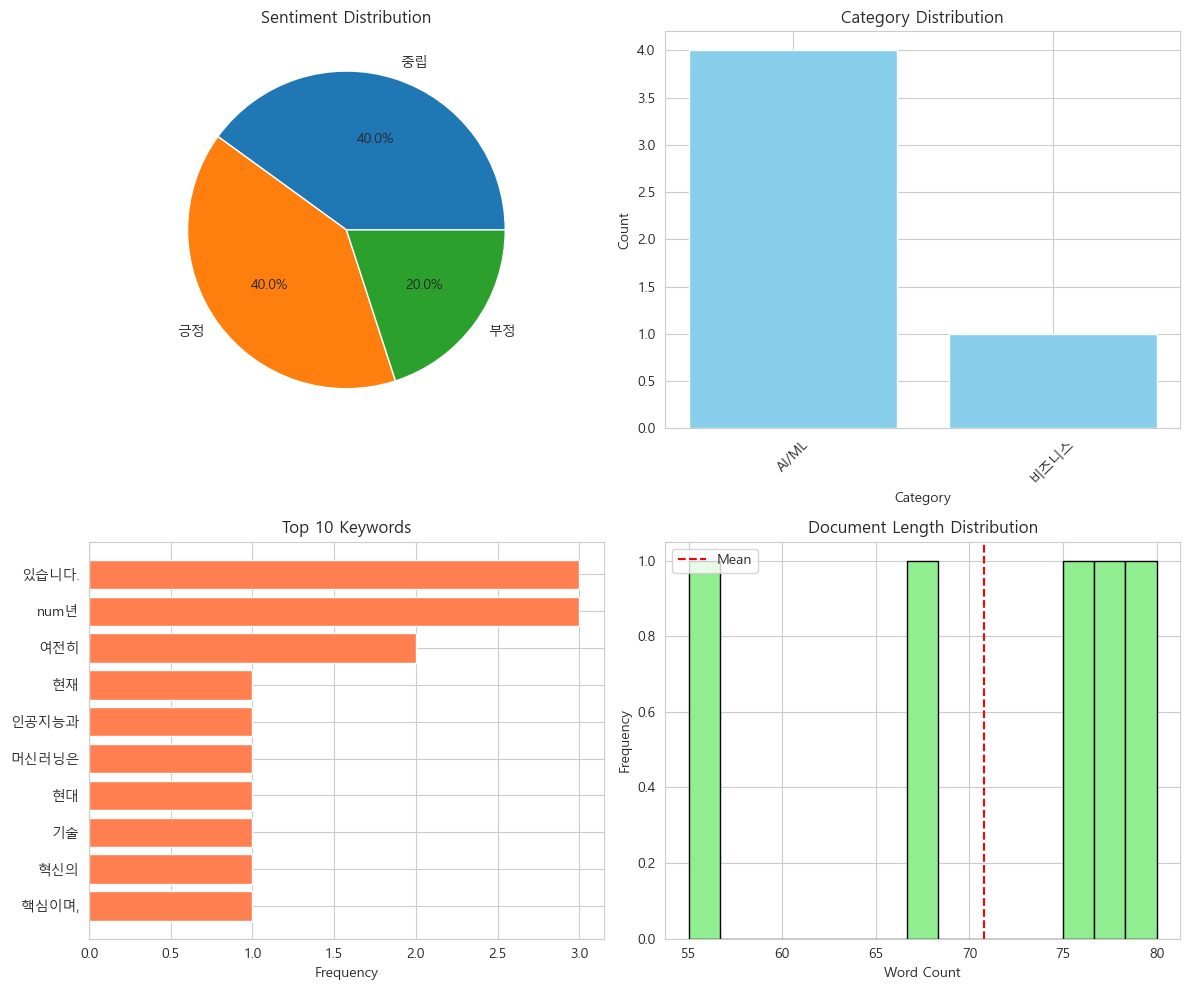

✓ 시각화 저장: ./reports\analysis_visualization.png


In [11]:
# 시각화 생성
print("=== 시각화 생성 ===")
report_gen.generate_visualization(results, DIRS['reports'])

## 개별 텍스트 분석 테스트

새로운 텍스트를 직접 입력하여 분석할 수 있습니다.

In [12]:
# 개별 텍스트 분석
def analyze_single_text(text, analyzer):
    """단일 텍스트 분석 및 출력"""
    result = analyzer.analyze(text)
    
    print("=" * 50)
    print("텍스트 분석 결과")
    print("=" * 50)
    
    print(f"\n[통계]")
    for key, value in result['statistics'].items():
        if isinstance(value, float):
            print(f"  {key}: {value:.2f}")
        else:
            print(f"  {key}: {value}")
    
    print(f"\n[감정 분석]")
    print(f"  레이블: {result['sentiment']['label']}")
    print(f"  신뢰도: {result['sentiment']['confidence']:.2%}")
    
    print(f"\n[카테고리]")
    print(f"  카테고리: {result['category']['category']}")
    print(f"  신뢰도: {result['category']['confidence']:.2%}")
    
    print(f"\n[상위 키워드]")
    for keyword, freq in result['keywords'][:5]:
        print(f"  - {keyword}: {freq}회")
    
    print(f"\n[주요 바이그램]")
    for bigram, freq in result['bigrams'][:3]:
        print(f"  - {bigram}: {freq}회")
    
    return result

# 테스트
test_text = """
2025년 현재 딥러닝과 머신러닝은 인공지능 기술의 핵심이자 가장 빠르게 성장하는 분야로, 의료, 금융, 제조, 교육 등 거의 모든 산업에서 우수한 혁신을 이끌고 있습니다.
파이썬을 사용하면 비교적 짧은 코드로도 모델을 쉽게 구현할 수 있으며, TensorFlow, PyTorch, Scikit-learn 같은 강력한 라이브러리가 지속적으로 발전하여 연구자와 개발자 모두에게 큰 도움을 주고 있습니다.
이러한 기술들은 이미 우리의 생활 속에 깊이 들어와 있고 앞으로 더 많은 기회를 만들어 줄 것이며, AI 기반의 미래는 지금보다 훨씬 더 밝고 풍요로울 것이라는 전망이 이어지고 있습니다!
"""

analysis_result = analyze_single_text(test_text, analyzer)

텍스트 분석 결과

[통계]
  char_count: 331
  word_count: 76
  sentence_count: 3
  avg_word_length: 3.34
  unique_word_ratio: 0.97
  punctuation_count: 11

[감정 분석]
  레이블: 긍정
  신뢰도: 50.00%

[카테고리]
  카테고리: AI/ML
  신뢰도: 62.50%

[상위 키워드]
  - 있습니다.: 2회
  - num년: 1회
  - 현재: 1회
  - 딥러닝과: 1회
  - 머신러닝은: 1회

[주요 바이그램]
  - num년 현재: 1회
  - 현재 딥러닝과: 1회
  - 딥러닝과 머신러닝은: 1회


## 학습 내용 정리

### 구현한 주요 기능

| 모듈 | 기능 | 주요 메서드 |
|------|------|------------|
| TextPreprocessor | 텍스트 전처리 | clean_text(), tokenize(), normalize() |
| FeatureExtractor | 특징 추출 | extract_bow(), extract_tfidf(), extract_statistics() |
| TextAnalyzer | 통합 분석 | train(), analyze(), save_model() |
| FileProcessor | 파일 입출력 | read_text_file(), process_directory() |
| ReportGenerator | 리포트 생성 | generate_text_report(), generate_visualization() |

### 분석 기능

| 기능 | 설명 |
|------|------|
| 전처리 | HTML/URL 제거, 정규화, 토큰화, 불용어 제거 |
| 통계 분석 | 단어 수, 문장 수, 평균 길이 등 |
| 감정 분석 | 긍정/부정/중립 분류 |
| 카테고리 분류 | AI/ML, 개발, 데이터, 비즈니스 |
| 키워드 추출 | 빈도 기반 상위 키워드 |
| N-gram 분석 | 연속 단어 패턴 추출 |

### 실습 완료 체크리스트

✓ 텍스트 전처리 파이프라인 구축  
✓ 특징 추출 모듈 구현  
✓ 통합 분석 엔진 개발  
✓ 파일 기반 배치 처리  
✓ 분석 리포트 자동 생성  
✓ 결과 시각화  
✓ 모델 저장 및 로드